In [1]:
# Imports
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.rcParams['figure.figsize'] = (15.0, 8.0) # set default size of plots
plt.rcParams['figure.facecolor'] = 'white'

pd.set_option('display.max_rows', None)

matplotlib.rcParams.update({'font.size': 15})

In [3]:
TIME_RETRIEVAL_REE = 0
TIME_RETRIEVAL_TEE = 5
TIME_RETRIEVAL_REE_WASM = 0
TIME_RETRIEVAL_TEE_WASM = 5

In [4]:
def compute_mean_std(size, time, factor = 1):
    df = pd.DataFrame(columns = ["Size","Time"])
    df["Size"] = size
    df["Time"] = time * factor
    
    result = pd.DataFrame(columns = ["Size","Mean","Std"])
    result["Mean"] = df.groupby("Size")["Time"].median() #df.groupby("Size")["Time"].apply(stats.gmean)
    result["Std"] = df.groupby("Size")["Time"].std() #df.groupby("Size")["Time"].apply(stats.gstd)
    result["Size"] = df.groupby("Size").groups.keys()
    
    return result

def formatForLatex(n):
    roundedAsString = str(round(n, 0))
    if "." in roundedAsString:
        roundedAsString = roundedAsString.rstrip("0")
        roundedAsString = roundedAsString.rstrip(".")
    return f"{roundedAsString}"

In [5]:
# Import the dataset
columns = ["Size","LaunchStart","MemoryStart","MemoryEnd","HashStart","HashEnd","InitEnd","LoadEnd","InstantiateEnd","LaunchEnd"]
launchtime_raw = pd.read_csv("../logs/launch-time/general.csv", names = columns)

display(launchtime_raw)

,Size,LaunchStart,MemoryStart,MemoryEnd,HashStart,HashEnd,InitEnd,LoadEnd,InstantiateEnd,LaunchEnd
0,1,1769159182605236,1769159182621401,1769159182624469,1769159182624481,1769159182624486,1769159182646712,1769159183477855,1769159183536281,1769159183554250
1,1,1769159186230341,1769159186246483,1769159186249547,1769159186249562,1769159186249567,1769159186271809,1769159187103577,1769159187162404,1769159187181155
2,1,1769159189932575,1769159189948707,1769159189951772,1769159189951785,1769159189951790,1769159189974026,1769159190805157,1769159190862845,1769159190880784
3,1,1769159193778271,1769159193794449,1769159193797566,1769159193797577,1769159193797582,1769159193819881,1769159194650996,1769159194708679,1769159194726616
4,1,1769159197543381,1769159197559633,1769159197562699,1769159197562712,1769159197562717,1769159197584987,1769159198416121,1769159198474208,1769159198492539
5,1,1769159201977687,1769159201993799,1769159201996849,1769159201996861,1769159201996865,1769159202019099,1769159202850277,1769159202908278,1769159202926230
6,1,1769159205773730,1769159205789946,1769159205793001,1769159205793014,1769159205793018,1769159205815243,1769159206646333,1769159206704029,1769159206721968
7,1,1769159209485260,1769159209501416,1769159209504472,1769159209504486,1769159209504491,1769159209526739,1769159210357906,1769159210415608,1769159210433550
8,1,1769159213200872,1769159213216989,1769159213220075,1769159213220091,1769159213220096,1769159213242387,1769159214073642,1769159214131334,1769159214149277
9,1,1769159216860995,1769159216877221,1769159216880307,1769159216880320,1769159216880326,1769159216902591,1769159217733820,1769159217791951,1769159217809936


In [6]:
# Summary of the gathered timespans
launchtime = pd.DataFrame()
launchtime["Size"] = launchtime_raw["Size"]

launchtime["LaunchSpan"] = launchtime_raw["LaunchEnd"] - launchtime_raw["LaunchStart"] \
                        - TIME_RETRIEVAL_REE/2 - 7*TIME_RETRIEVAL_TEE - TIME_RETRIEVAL_TEE_WASM/2

launchtime["TransitionSpan"] = launchtime_raw["MemoryStart"] - launchtime_raw["LaunchStart"] \
                        - TIME_RETRIEVAL_REE/2 - TIME_RETRIEVAL_TEE/2

launchtime["MemorySpan"] = launchtime_raw["MemoryEnd"] - launchtime_raw["MemoryStart"] \
                        - 2*TIME_RETRIEVAL_TEE/2

launchtime["HashSpan"] = launchtime_raw["HashEnd"] - launchtime_raw["HashStart"] \
                        - 2*TIME_RETRIEVAL_TEE/2

launchtime["WasmInitSpan"] = launchtime_raw["InitEnd"] - launchtime_raw["HashEnd"] \
                        - 2*TIME_RETRIEVAL_TEE/2

launchtime["WasmLoadSpan"] = launchtime_raw["LoadEnd"] - launchtime_raw["InitEnd"] \
                        - 2*TIME_RETRIEVAL_TEE/2

launchtime["WasmInstantiateSpan"] = launchtime_raw["InstantiateEnd"] - launchtime_raw["LoadEnd"] \
                        - 2*TIME_RETRIEVAL_TEE/2

launchtime["WasmExecutionSpan"] = launchtime_raw["LaunchEnd"] - launchtime_raw["InstantiateEnd"] \
                        - TIME_RETRIEVAL_TEE/2 - TIME_RETRIEVAL_TEE_WASM/2

launchtime["OtherSpan"] = launchtime["LaunchSpan"] - launchtime["TransitionSpan"] - launchtime["MemorySpan"] \
                        - launchtime["HashSpan"] - launchtime["WasmInitSpan"] - launchtime["WasmLoadSpan"] \
                        - launchtime["WasmInstantiateSpan"] - launchtime["WasmExecutionSpan"]

launchtime

,Size,LaunchSpan,TransitionSpan,MemorySpan,HashSpan,WasmInitSpan,WasmLoadSpan,WasmInstantiateSpan,WasmExecutionSpan,OtherSpan
0,1,948976.5,16162.5,3063.0,0.0,22221.0,831138.0,58421.0,17964.0,7.0
1,1,950776.5,16139.5,3059.0,0.0,22237.0,831763.0,58822.0,18746.0,10.0
2,1,948171.5,16129.5,3060.0,0.0,22231.0,831126.0,57683.0,17934.0,8.0
3,1,948307.5,16175.5,3112.0,0.0,22294.0,831110.0,57678.0,17932.0,6.0
4,1,949120.5,16249.5,3061.0,0.0,22265.0,831129.0,58082.0,18326.0,8.0
5,1,948505.5,16109.5,3045.0,-1.0,22229.0,831173.0,57996.0,17947.0,7.0
6,1,948200.5,16213.5,3050.0,-1.0,22220.0,831085.0,57691.0,17934.0,8.0
7,1,948252.5,16153.5,3051.0,0.0,22243.0,831162.0,57697.0,17937.0,9.0
8,1,948367.5,16114.5,3081.0,0.0,22286.0,831250.0,57687.0,17938.0,11.0
9,1,948903.5,16223.5,3081.0,1.0,22260.0,831224.0,58126.0,17980.0,8.0


In [7]:
# Compute the mean and std
launch_span = compute_mean_std(launchtime_raw["Size"], launchtime["LaunchSpan"], factor=0.001)
launch_span

,Size,Mean,Std
Size,,,
1,1,948.3705,0.710766
2,2,967.4740,4.464650
3,3,990.9505,6.605511


In [8]:
transition_span = compute_mean_std(launchtime_raw["Size"], launchtime["TransitionSpan"], factor=0.001)
transition_span

,Size,Mean,Std
Size,,,
1,1,16.2085,0.127344
2,2,16.2960,0.093582
3,3,16.4105,0.114033


In [9]:
memory_span = compute_mean_std(launchtime_raw["Size"], launchtime["MemorySpan"], factor=0.001)
memory_span

,Size,Mean,Std
Size,,,
1,1,3.0735,0.139567
2,2,6.0925,0.144667
3,3,9.1030,0.201264


In [10]:
hash_span = compute_mean_std(launchtime_raw["Size"], launchtime["HashSpan"], factor=0.001)
hash_span

,Size,Mean,Std
Size,,,
1,1,0.0,0.000865
2,2,0.0,0.000750
3,3,0.0,0.000906


In [11]:
wasm_init_span = compute_mean_std(launchtime_raw["Size"], launchtime["WasmInitSpan"], factor=0.001)
wasm_init_span

,Size,Mean,Std
Size,,,
1,1,22.2545,0.153117
2,2,23.4730,0.108247
3,3,24.6910,0.104502


In [12]:
wasm_load_span = compute_mean_std(launchtime_raw["Size"], launchtime["WasmLoadSpan"], factor=0.001)
wasm_load_span

,Size,Mean,Std
Size,,,
1,1,831.1415,0.278167
2,2,845.9290,4.414678
3,3,865.0240,6.566811


In [13]:
wasm_instantiate_span = compute_mean_std(launchtime_raw["Size"], launchtime["WasmInstantiateSpan"], factor=0.001)
wasm_instantiate_span

,Size,Mean,Std
Size,,,
1,1,57.6990,0.299083
2,2,57.6950,0.298376
3,3,57.7025,0.290347


In [14]:
wasm_execution_span = compute_mean_std(launchtime_raw["Size"], launchtime["WasmExecutionSpan"], factor=0.001)
wasm_execution_span

,Size,Mean,Std
Size,,,
1,1,17.937,0.145397
2,2,17.936,0.152619
3,3,17.938,0.111698


In [15]:
other_span = compute_mean_std(launchtime_raw["Size"], launchtime["OtherSpan"], factor=0.001)
other_span

,Size,Mean,Std
Size,,,
1,1,0.008,0.013872
2,2,0.009,0.002553
3,3,0.009,0.001772


Text(0, 0.5, 'Time in microseconds')

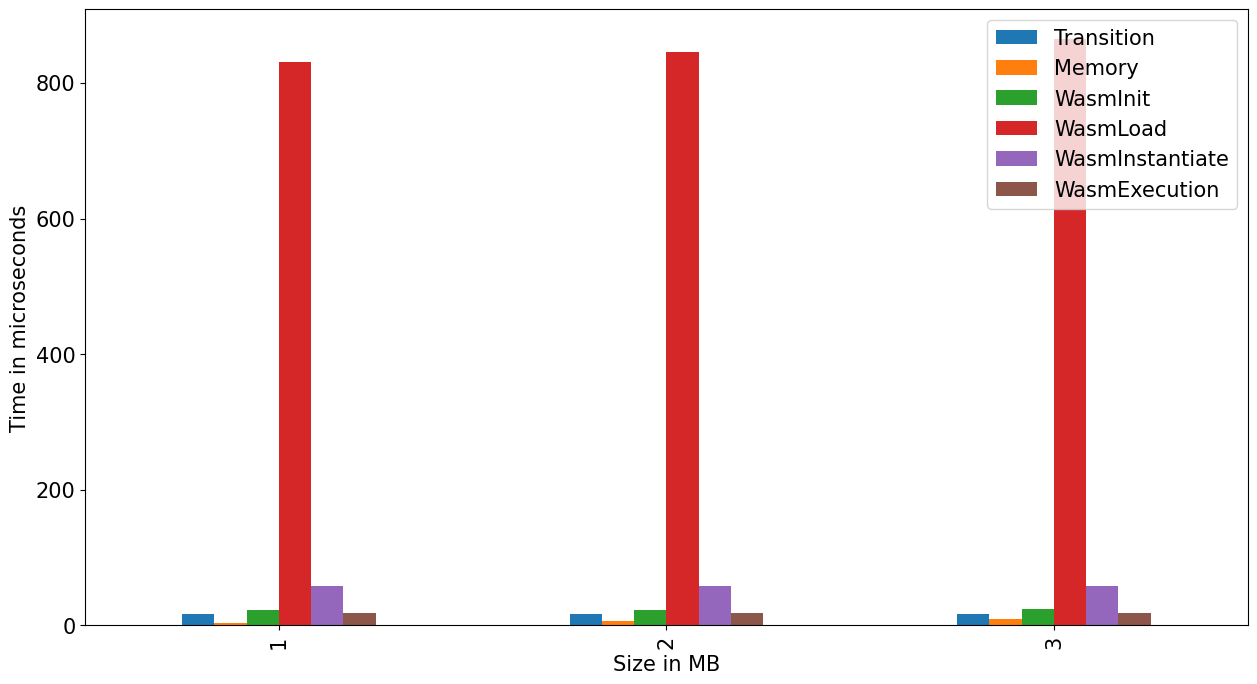

In [16]:
# Draw the area plot
area_plot_data = pd.DataFrame()
area_plot_data["Transition"] = transition_span["Mean"]
area_plot_data["Memory"] = memory_span["Mean"]
# area_plot_data["Hash"] = hash_span["Mean"]
area_plot_data["WasmInit"] = wasm_init_span["Mean"]
area_plot_data["WasmLoad"] = wasm_load_span["Mean"]
area_plot_data["WasmInstantiate"] = wasm_instantiate_span["Mean"]
area_plot_data["WasmExecution"] = wasm_execution_span["Mean"]

ax = area_plot_data.plot.bar() # .area()
ax.set_xlabel("Size in MB")
ax.set_ylabel("Time in microseconds")

In [17]:
#
# Show the ratio of the elements
#

ratio = pd.DataFrame()
ratio["Transition"] = transition_span["Mean"] / launch_span["Mean"]
ratio["Memory"] = memory_span["Mean"] / launch_span["Mean"]
ratio["Hash"] = hash_span["Mean"] / launch_span["Mean"]
ratio["WasmInit"] = wasm_init_span["Mean"] / launch_span["Mean"]
ratio["WasmLoad"] = wasm_load_span["Mean"] / launch_span["Mean"]
ratio["WasmInstantiate"] = wasm_instantiate_span["Mean"] / launch_span["Mean"]
ratio["WasmExecution"] = wasm_execution_span["Mean"] / launch_span["Mean"]

ratio

,Transition,Memory,Hash,WasmInit,WasmLoad,WasmInstantiate,WasmExecution
Size,,,,,,,
1,0.017091,0.003241,0.0,0.023466,0.876389,0.060840,0.018913
2,0.016844,0.006297,0.0,0.024262,0.874369,0.059635,0.018539
3,0.016560,0.009186,0.0,0.024916,0.872924,0.058229,0.018102


In [18]:
ratio.mean() * 100

Transition          1.683171
Memory              0.624143
Hash                0.000000
WasmInit            2.421489
WasmLoad           87.456042
WasmInstantiate     5.956809
WasmExecution       1.851810
dtype: float64

In [19]:
# Export CSV
#
# File format: experiment_name, mean, stddev

transition_span.drop(columns="Size").to_csv('../logs/launch-time/transition_formatted.csv')
memory_span.drop(columns="Size").to_csv('../logs/launch-time/memory_formatted.csv')
hash_span.drop(columns="Size").to_csv('../logs/launch-time/hash_formatted.csv')
wasm_init_span.drop(columns="Size").to_csv('../logs/launch-time/wasm_init_formatted.csv')
wasm_load_span.drop(columns="Size").to_csv('../logs/launch-time/wasm_load_formatted.csv')
wasm_instantiate_span.drop(columns="Size").to_csv('../logs/launch-time/wasm_instantiate_formatted.csv')
wasm_execution_span.drop(columns="Size").to_csv('../logs/launch-time/wasm_execution_formatted.csv')

In [ ]:
# Export LaTeX

ratio_median = ratio.median()
prefix = "LaunchTime"

def write_ratio(file, column_name, ratio):
    f.write(f"\\def\\bm{prefix}{column_name}Ratio{{{formatForLatex(ratio * 100)}}}\n")

f = open('../logs/launch-time/export.tex', "w")
write_ratio(f, "WasmInit", ratio_median["WasmInit"])
write_ratio(f, "WasmLoad", ratio_median["WasmLoad"])
write_ratio(f, "Memory", ratio_median["Memory"])
write_ratio(f, "Hash", ratio_median["Hash"])
f.close()